## ライブラリの読み込み

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## 1. データの読み込み

In [15]:
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### データの基本確認
まずデータの行数・列数、カラム名、データ型を確認します。

In [6]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 2. 欠損値の確認

In [16]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [17]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [20]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [21]:
missing_ratio = df.isnull().mean().sort_values(ascending=False)
missing_ratio

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

## 3. 重複データの確認

In [22]:
df.duplicated().sum()

np.int64(0)

## 4. 目的変数Churnの確認

In [25]:
df["Churn"].value_counts()
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

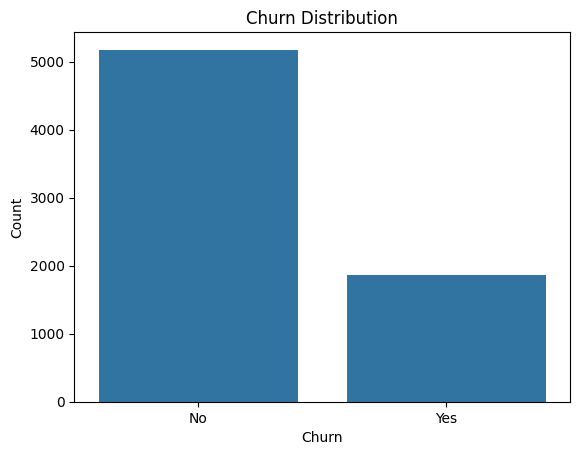

In [26]:
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [27]:
churn_rate = df["Churn"].value_counts(normalize=True)["Yes"]
print(f"Churn Rate: {churn_rate:.2%}")

Churn Rate: 26.54%


### メモ

目的変数の分布を見ると、解約していない顧客の方が多い。
そのため、モデル評価では Accuracy だけでなく、Recall や F1-score も確認する必要がある。

## 5. 数値変数の確認

In [29]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

df[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


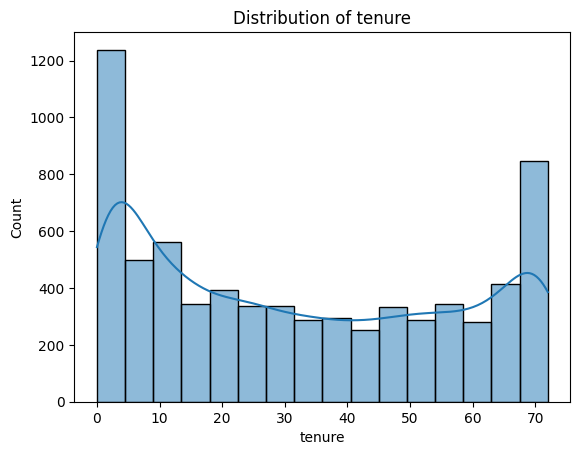

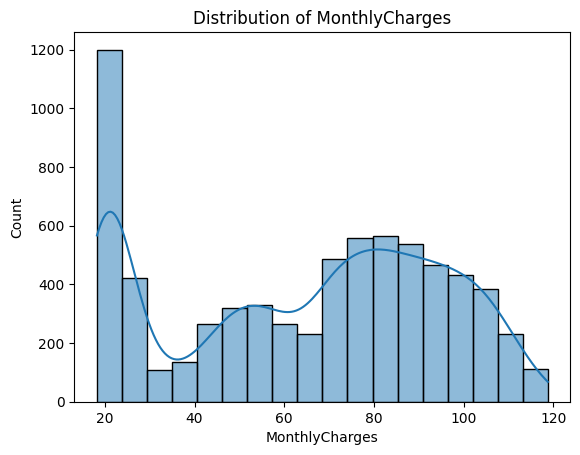

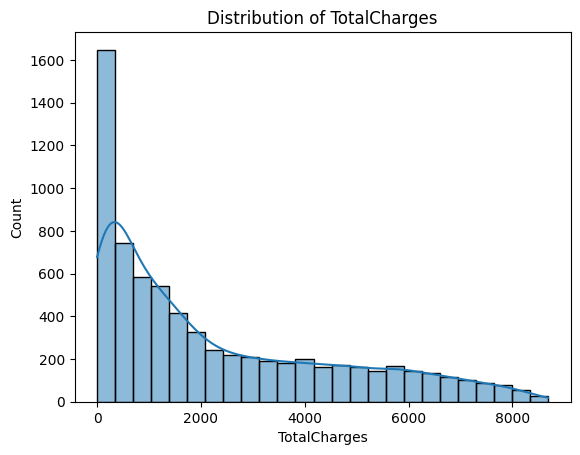

In [30]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## 6.数値変数とChurnの関係

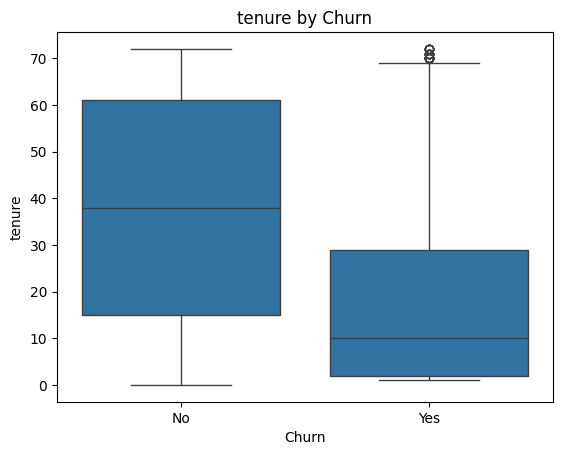

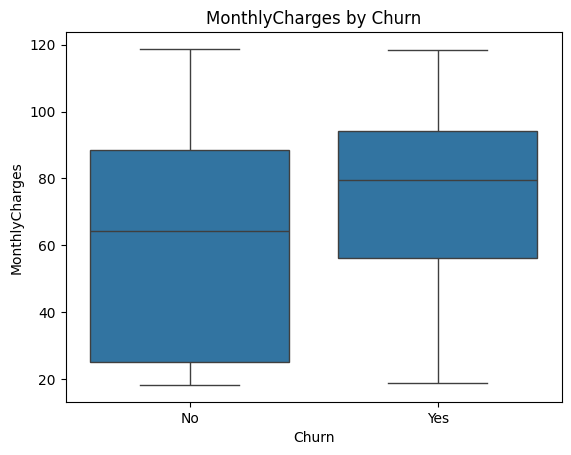

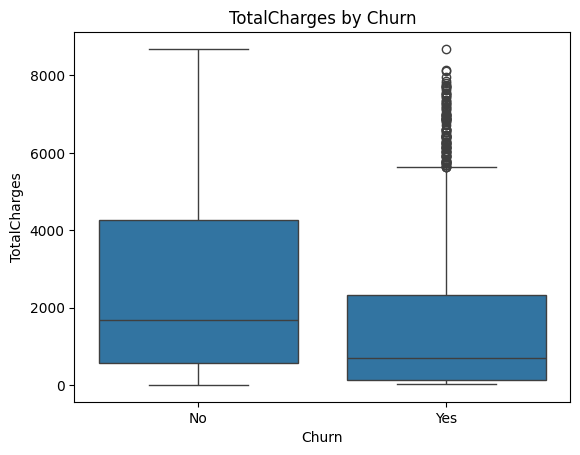

In [32]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(f"{col} by Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

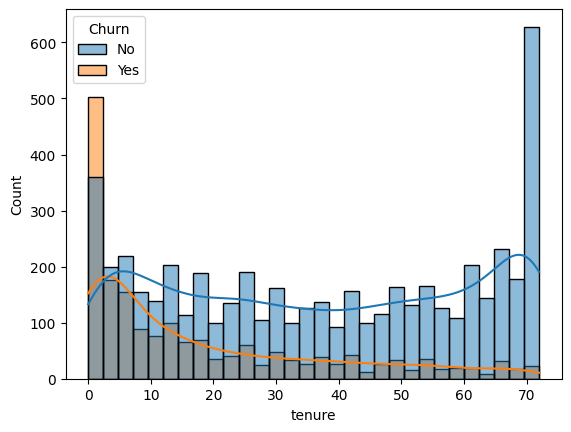

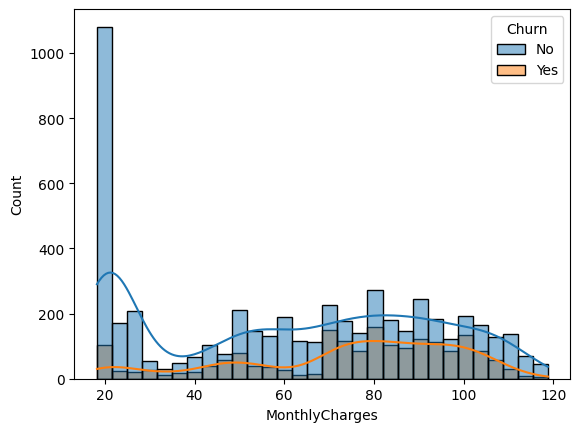

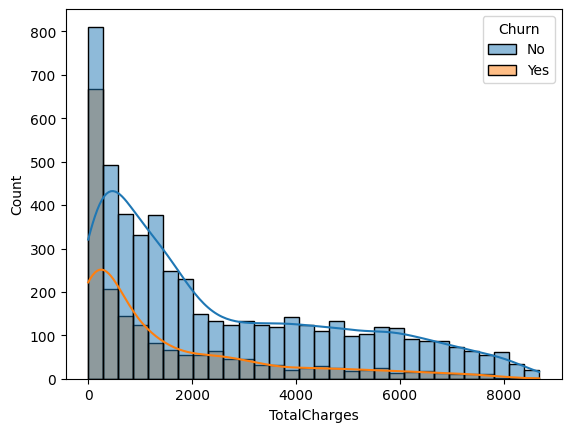

In [34]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(data=df, x=col, hue="Churn", kde=True, bins=30)
    plt.show()

### メモ

- tenure が短い顧客ほど解約しやすい可能性がある
- MonthlyCharges が高い顧客は解約率が高い可能性がある
- TotalCharges は tenure の影響を受けるため、単独

## 7. カテゴリ変数の確認

カテゴリ変数の種類と分布を確認します。

In [36]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
categorical_cols

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [37]:
categorical_cols = [col for col in categorical_cols if col not in ["customerID", "Churn"]]
categorical_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [38]:
for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

--- OnlineBackup ---
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

--- DeviceProtection ---
DeviceProtection
No                     3095
Yes                    2422
No internet service    

## 8. カテゴリ変数と Churn の関係

カテゴリごとの解約数を可視化します。

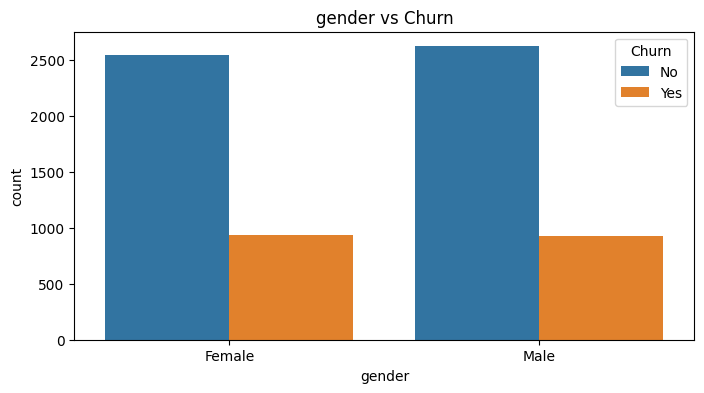

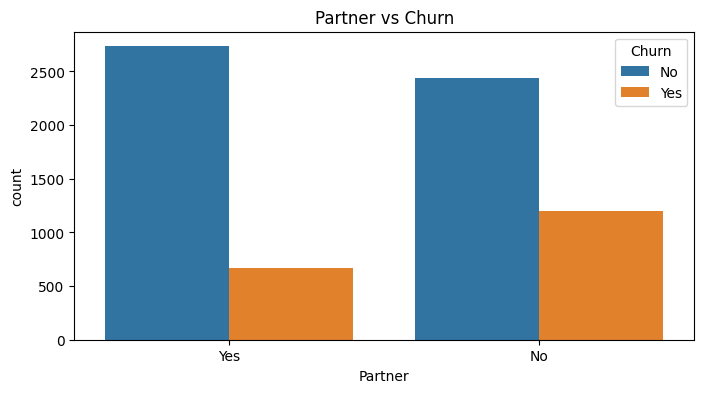

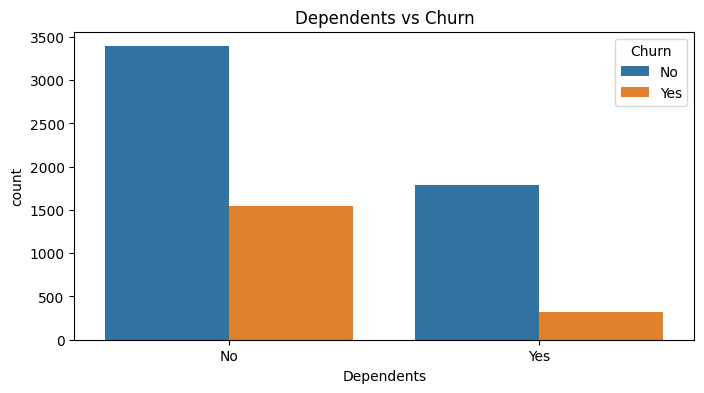

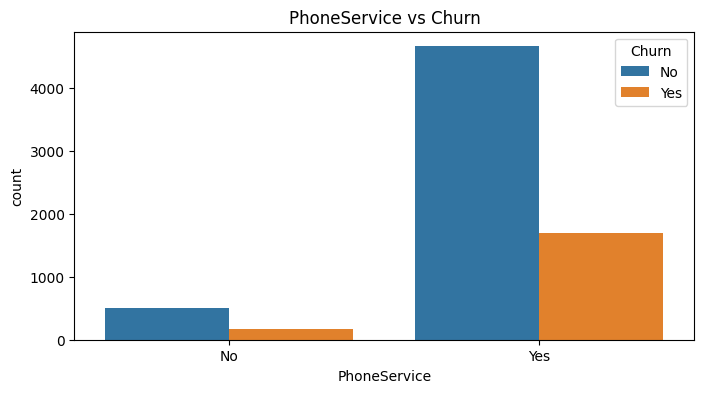

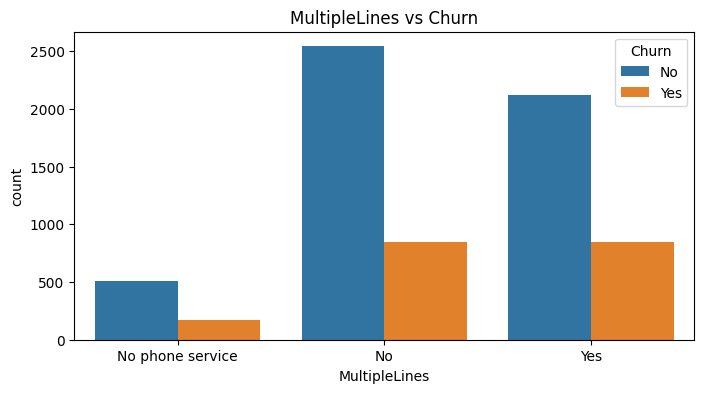

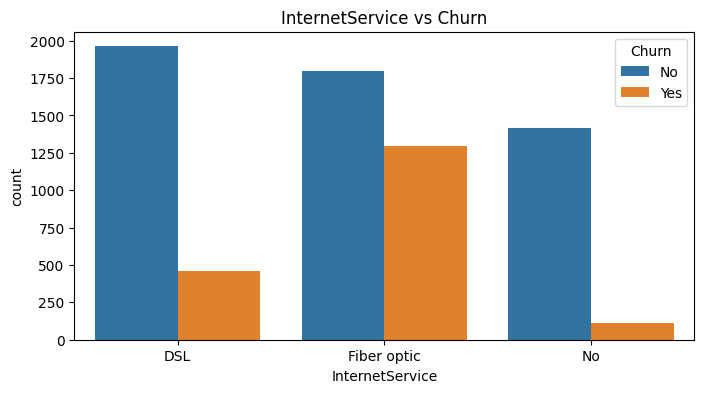

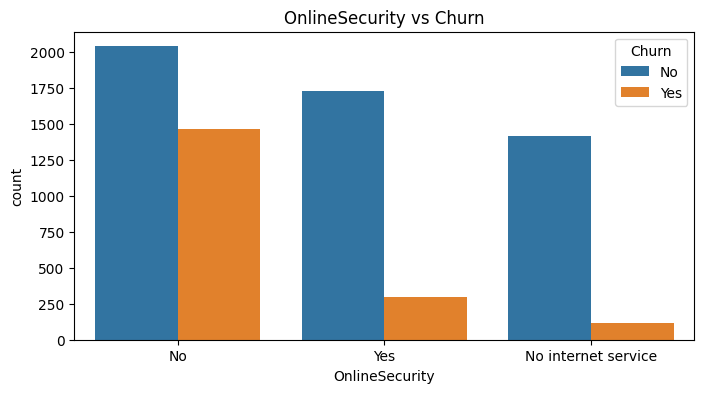

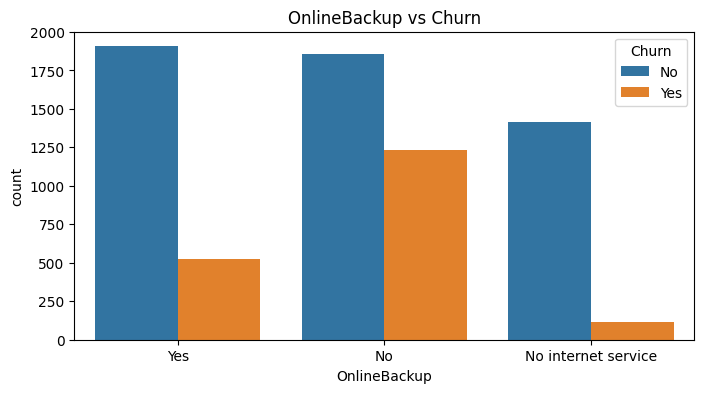

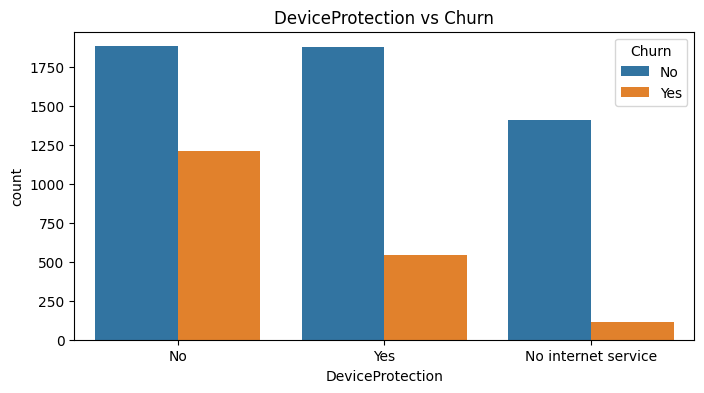

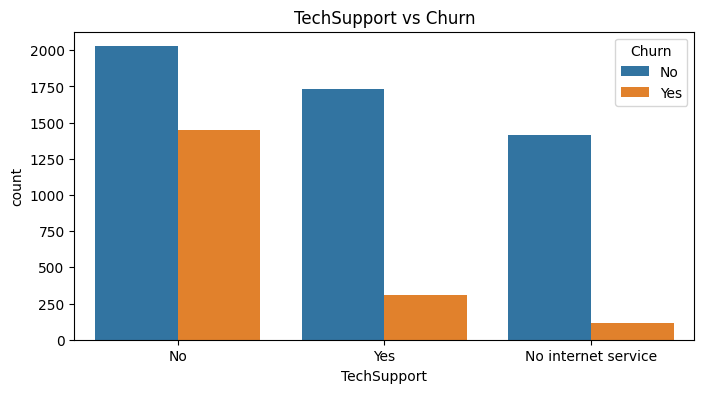

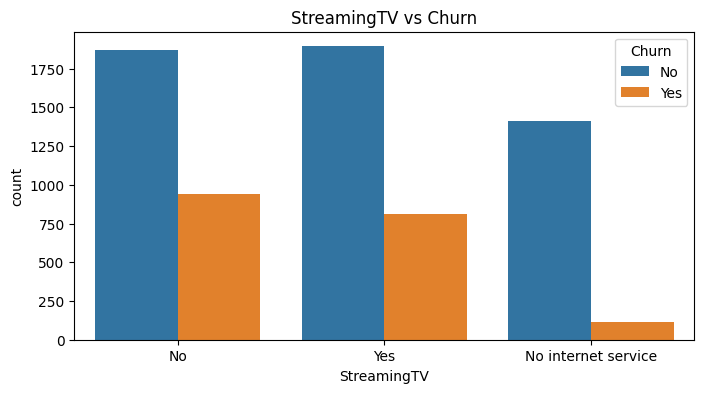

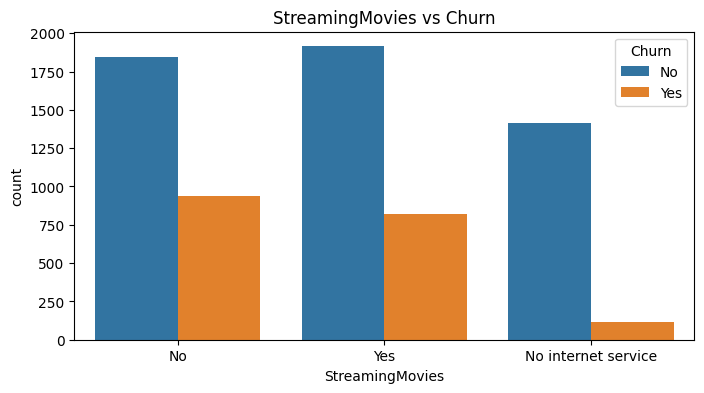

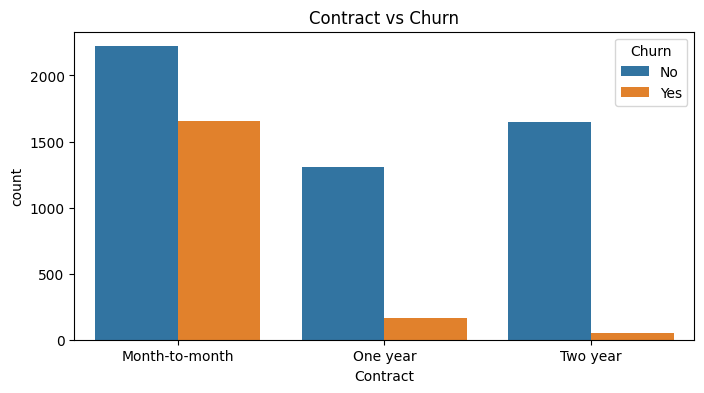

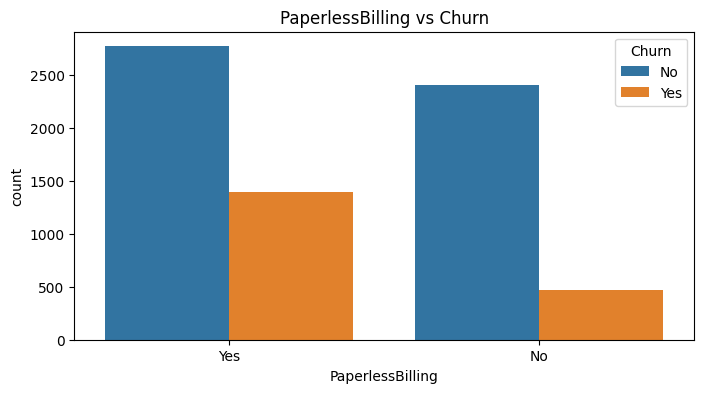

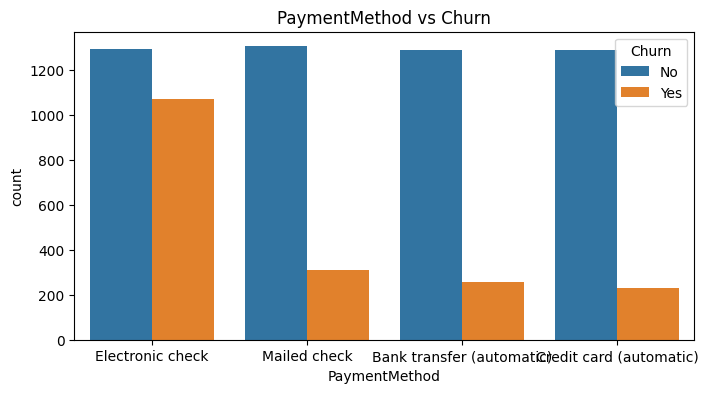

In [39]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue="Churn")
    plt.title(f"{col} vs Churn")
    plt.xlabel(col)


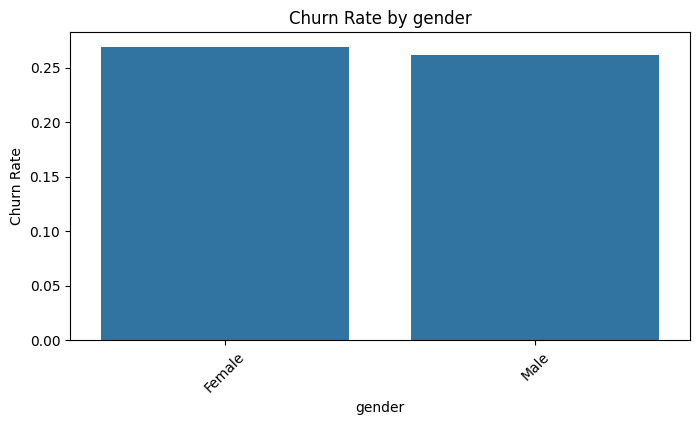

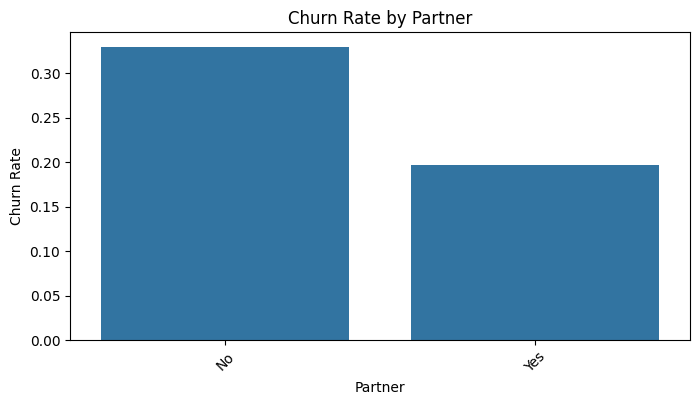

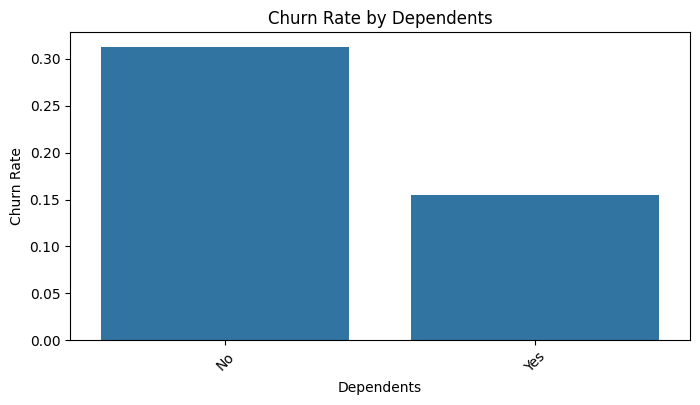

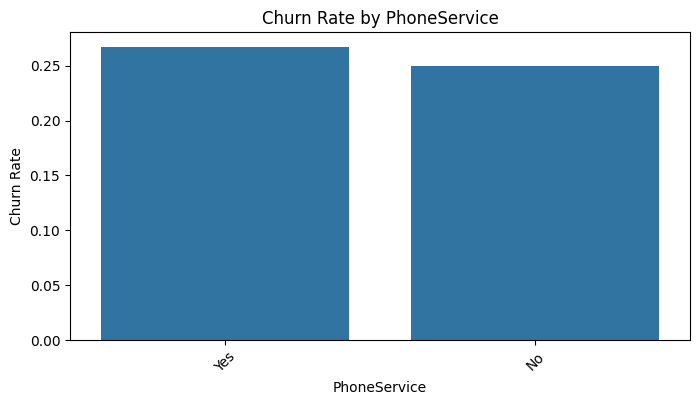

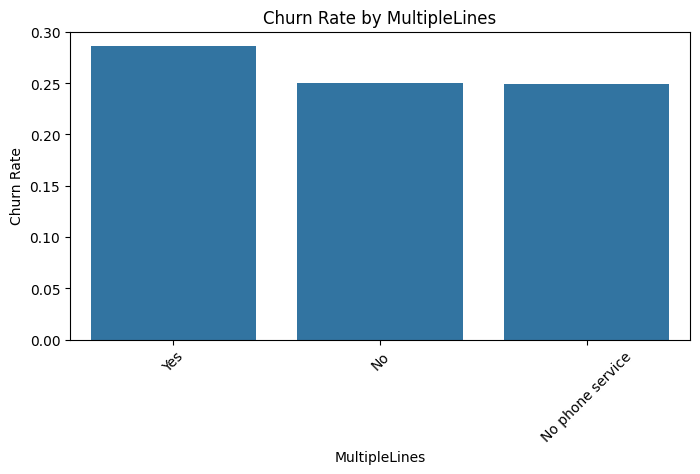

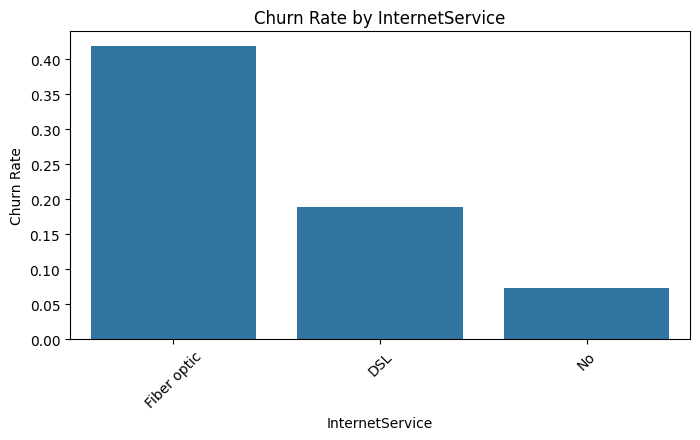

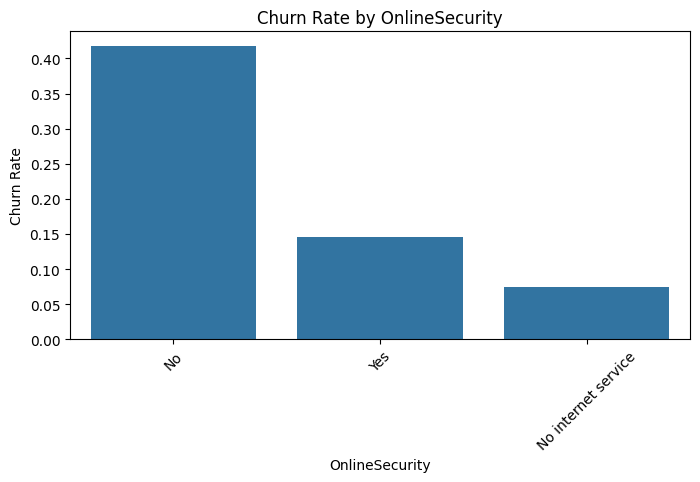

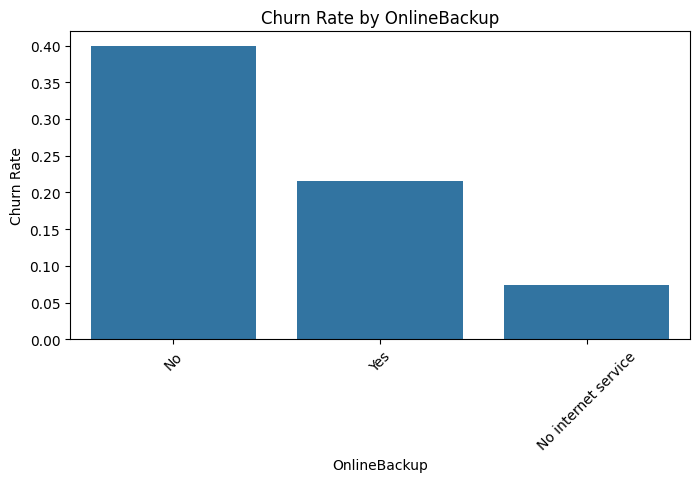

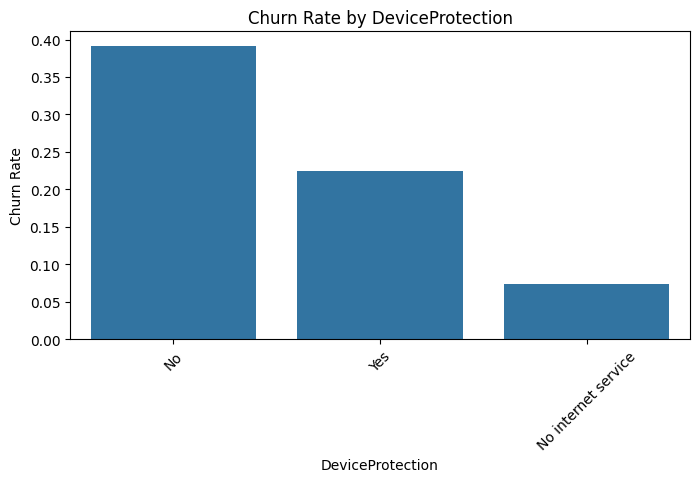

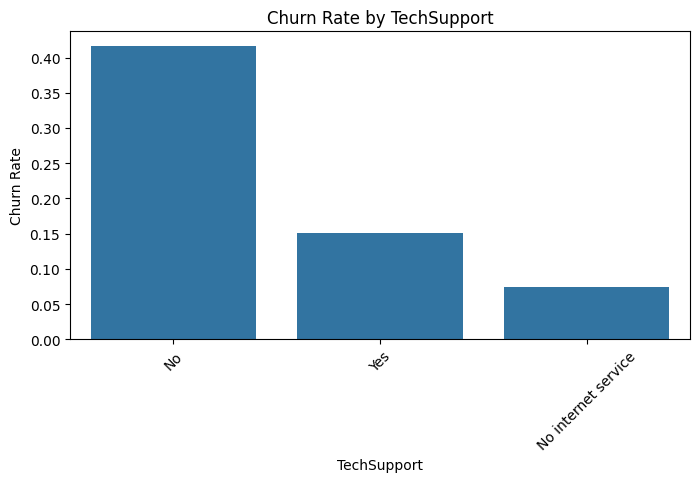

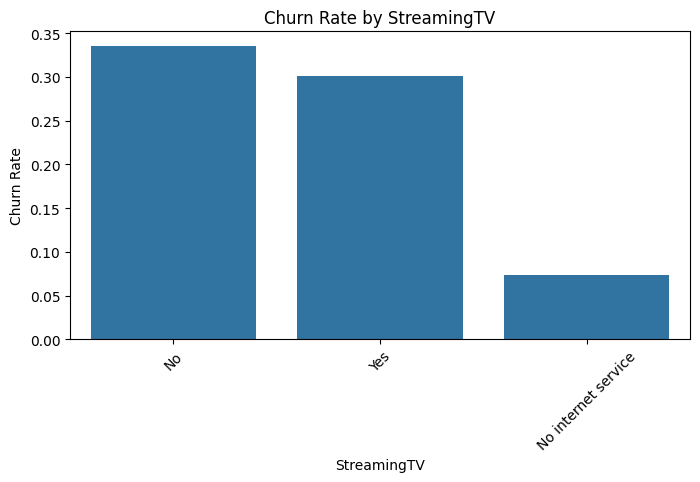

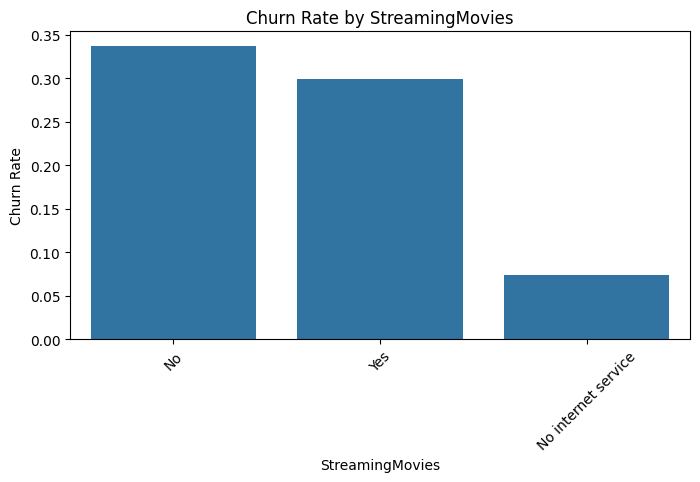

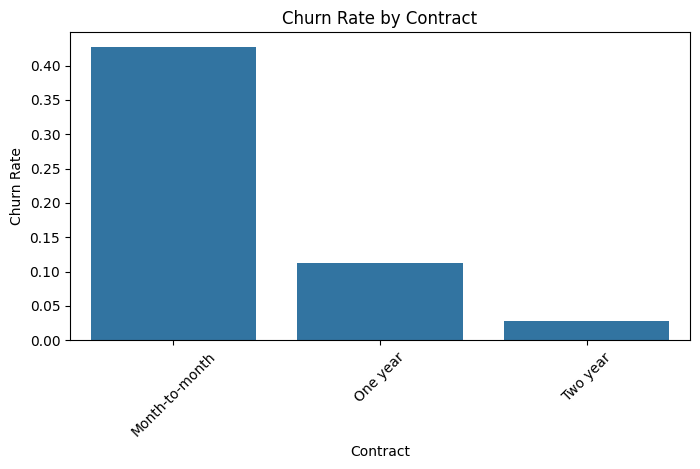

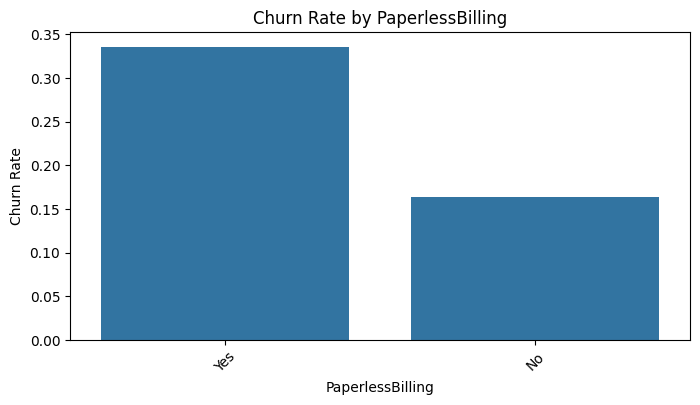

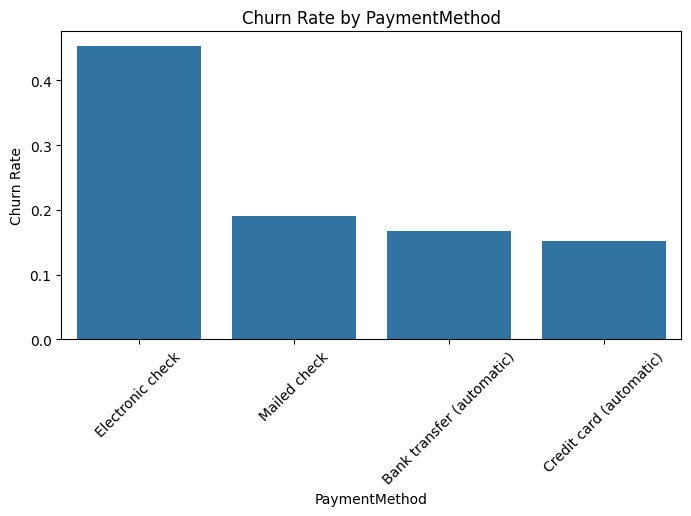

In [40]:
for col in categorical_cols:
    churn_rate_by_col = df.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean()).sort_values(ascending=False)
    
    plt.figure(figsize=(8, 4))
    sns.barplot(x=churn_rate_by_col.index, y=churn_rate_by_col.values)
    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn Rate")
    plt.xticks(rotation=45)
    plt.show()

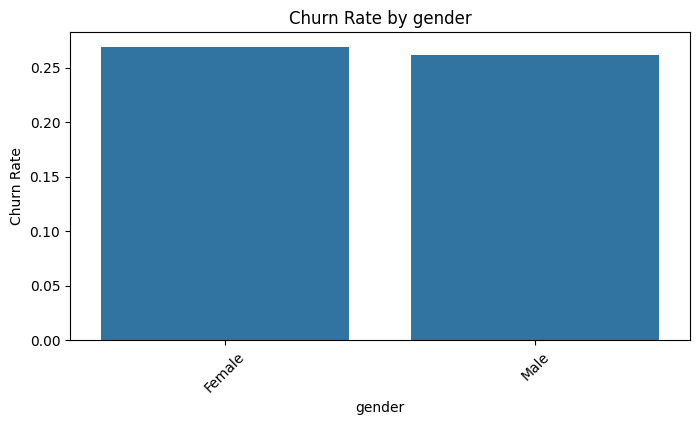

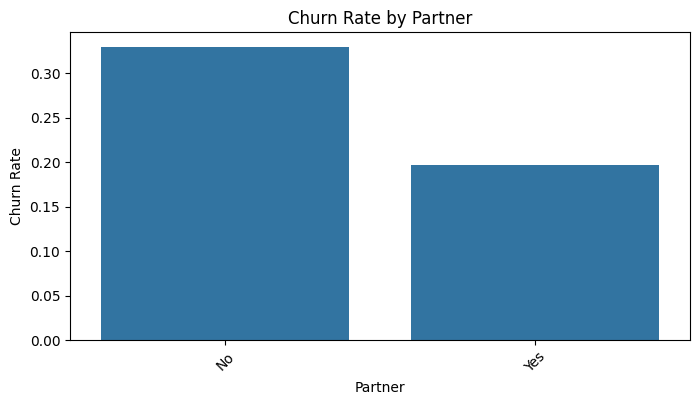

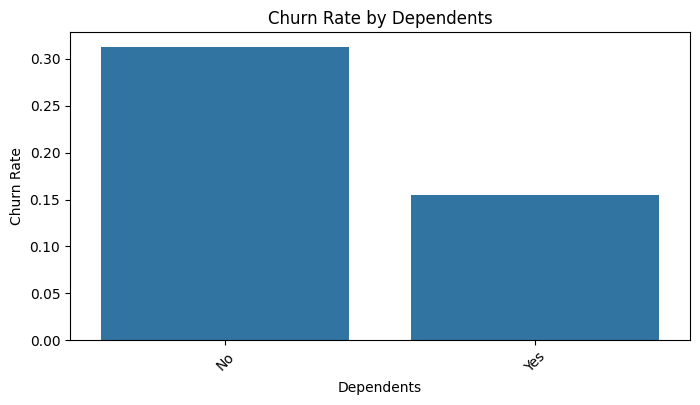

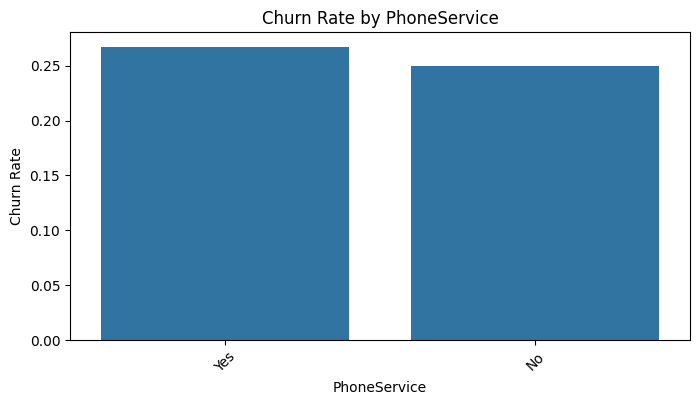

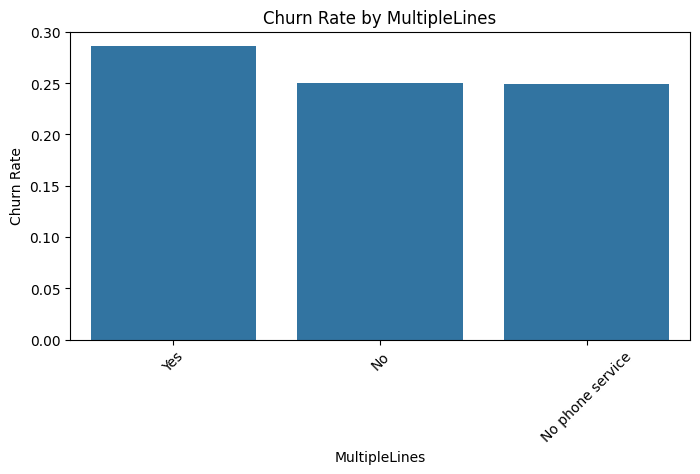

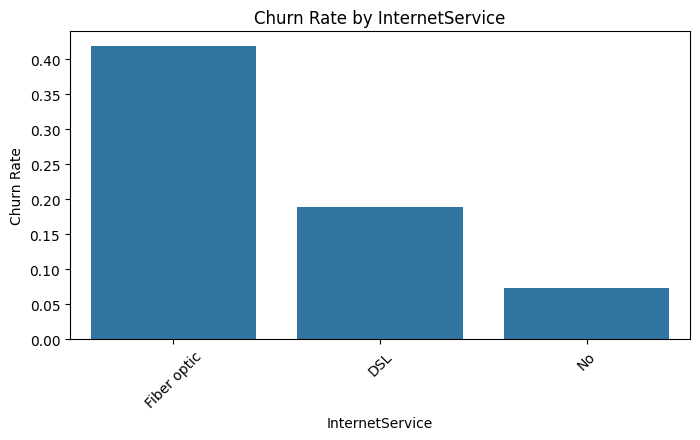

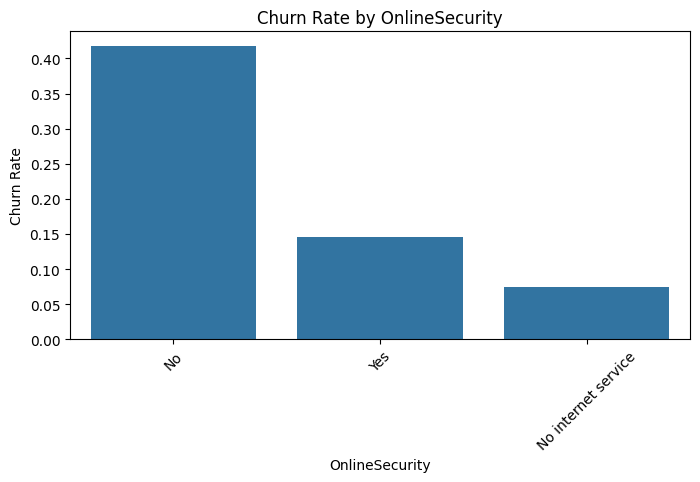

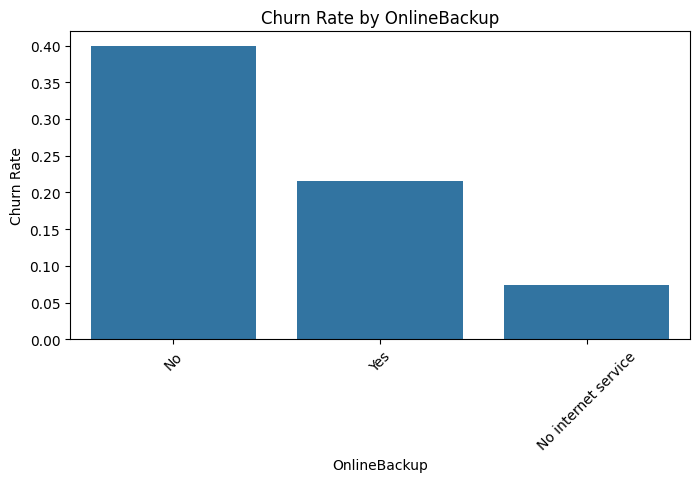

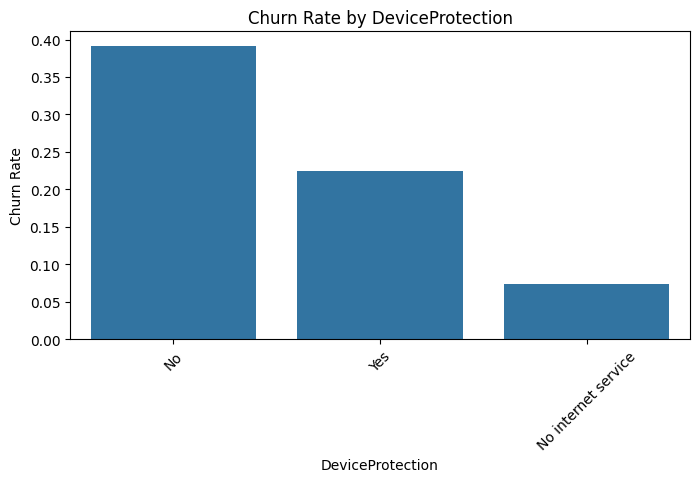

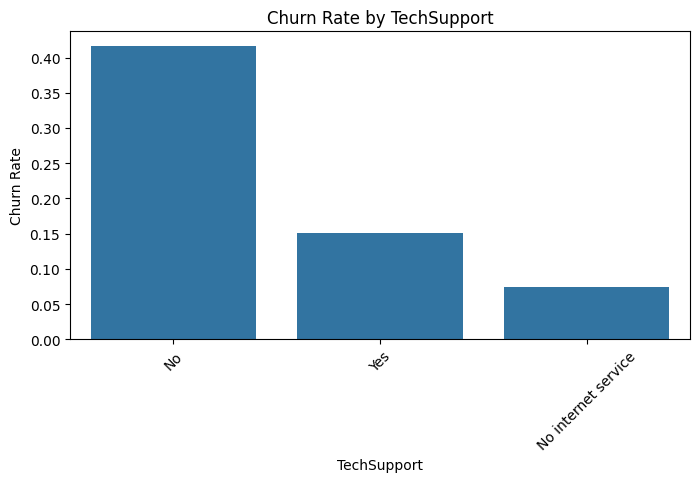

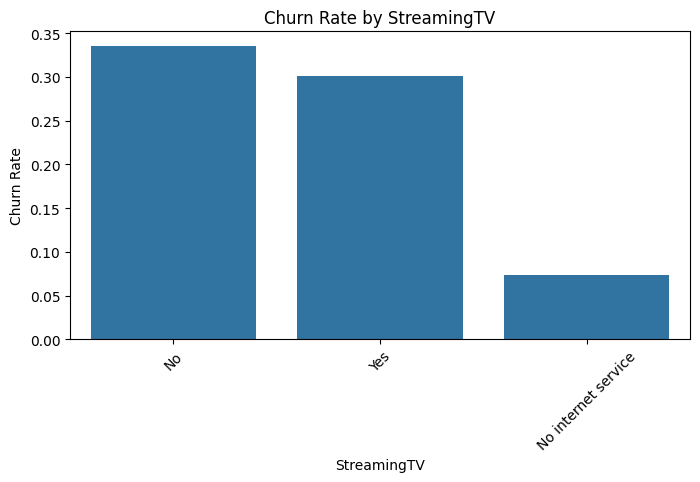

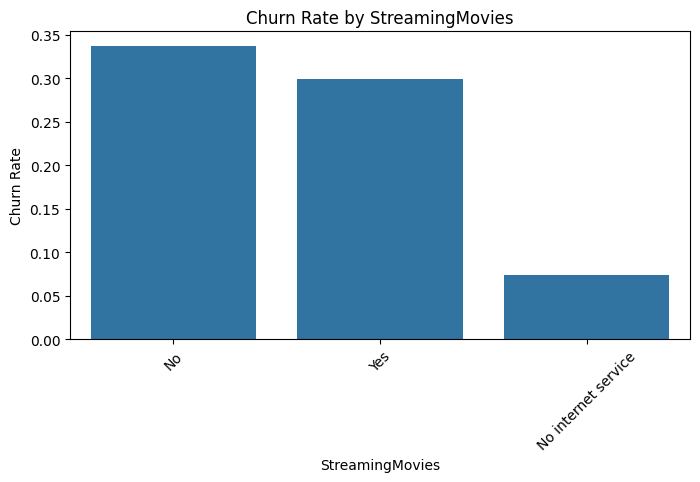

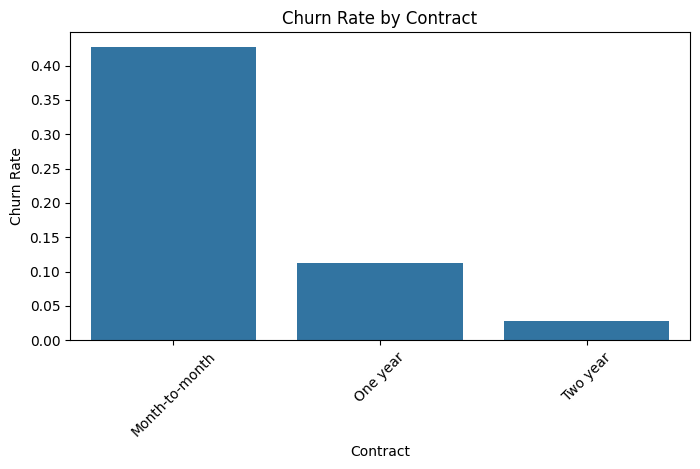

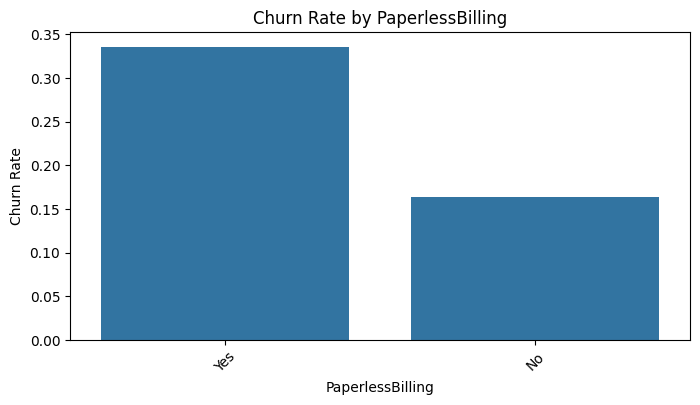

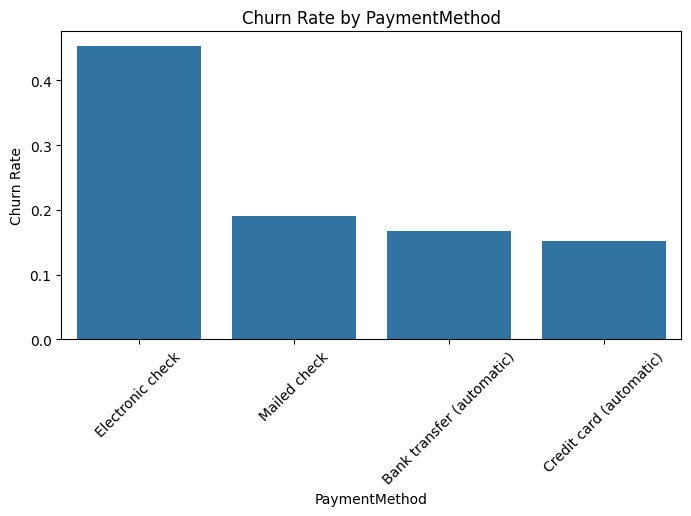

In [41]:
for col in categorical_cols:
    churn_rate_by_col = df.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean()).sort_values(ascending=False)
    
    plt.figure(figsize=(8, 4))
    sns.barplot(x=churn_rate_by_col.index, y=churn_rate_by_col.values)
    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn Rate")
    plt.xticks(rotation=45)
    plt.show()

## 9. 相関の確認

Churnを数値化して、数値変数との相関を確認します。

In [42]:
df_corr = df.copy()
df_corr["ChurnFlag"] = df_corr["Churn"].map({"No": 0, "Yes": 1})

In [43]:
corr_cols = ["tenure", "MonthlyCharges", "TotalCharges", "ChurnFlag"]
corr_matrix = df_corr[corr_cols].corr()
corr_matrix

,tenure,MonthlyCharges,TotalCharges,ChurnFlag
tenure,1.000000,0.247900,0.826178,-0.352229
MonthlyCharges,0.247900,1.000000,0.651174,0.193356
TotalCharges,0.826178,0.651174,1.000000,-0.198324
ChurnFlag,-0.352229,0.193356,-0.198324,1.000000


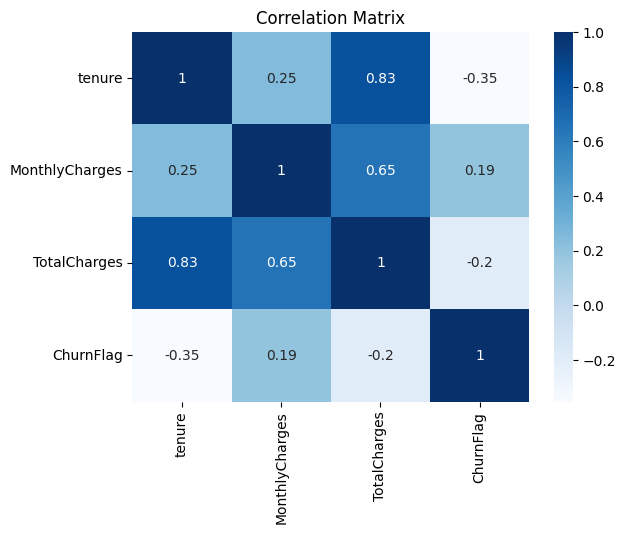

In [44]:
sns.heatmap(corr_matrix, annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

## 10. EDA Summary

今回の探索的データ分析から、以下の傾向が確認できました。

### 主な発見

1. 解約していない顧客の方が多く、目的変数にはやや偏りがある
2. tenure が短い顧客ほど解約しやすい傾向がある
3. Month-to-month 契約の顧客は解約率が高い傾向がある
4. MonthlyCharges が高い顧客は解約しやすい可能性がある
5. TechSupport や OnlineSecurity がない顧客は解約しやすい可能性がある
6. Electronic check を利用している顧客は解約率が高い可能性がある

### 次のステップ

次のNotebookでは、以下を行います。

- `TotalCharges` の欠損値処理
- `customerID` の削除
- カテゴリ変数のOne-Hot Encoding
- 学習データとテストデータの分割
- Logistic Regression, Random Forest, Gradient Boosting の比較
- Accuracy, Precision, Recall, F1-score, ROC-AUC による評価